<a href="https://colab.research.google.com/github/Thanish235/Hackathon/blob/main/anemia_detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
d=pd.read_csv(r"/content/BALANCED_ANEMIA_DATASET.csv")

In [3]:

d.head()


,Hemoglobin,MCV,MCH,MCHC,Gender,Result
0,12.7,87.2,29.5,33.8,1.0,1.0
1,12.8,85.0,29.5,34.7,1.0,1.0
2,9.4,86.5,29.6,34.2,1.0,1.0
3,10.5,93.7,31.3,33.4,1.0,1.0
4,5.1,109.2,38.9,35.7,1.0,1.0


In [4]:
y = d['Result']
x = d.drop(['Result'],axis=1)
x,y

(       Hemoglobin         MCV        MCH       MCHC  Gender
 0       12.700000   87.200000  29.500000  33.800000     1.0
 1       12.800000   85.000000  29.500000  34.700000     1.0
 2        9.400000   86.500000  29.600000  34.200000     1.0
 3       10.500000   93.700000  31.300000  33.400000     1.0
 4        5.100000  109.200000  38.900000  35.700000     1.0
 ...           ...         ...        ...        ...     ...
 65791   11.430621   83.733876  30.100000  35.900000     1.0
 65792    8.915793   65.512276  19.300000  29.477827     0.0
 65793   11.339630   78.400000  25.939630  33.093588     0.0
 65794   11.480453   80.556822  26.953638  33.460000     0.0
 65795   10.909791   82.916070  28.044767  33.821000     0.0
 
 [65796 rows x 5 columns],
 0        1.0
 1        1.0
 2        1.0
 3        1.0
 4        1.0
         ... 
 65791    1.0
 65792    1.0
 65793    1.0
 65794    1.0
 65795    1.0
 Name: Result, Length: 65796, dtype: float64)

In [5]:
X_train,X_temp,Y_train,Y_temp = train_test_split(
    x,y,train_size=0.7,random_state=42, stratify = y
)
X_train,X_temp

(       Hemoglobin        MCV        MCH       MCHC  Gender
 862     11.690000  81.390000  27.140000  33.340000     1.0
 57695   11.900000  79.065087  26.017456  32.927154     0.0
 25693   12.900000  88.500000  30.400000  34.308511     0.0
 15752   16.300000  88.700000  16.400000  27.800000     0.0
 56964    9.966015  68.786797  21.556602  31.369805     1.0
 ...           ...        ...        ...        ...     ...
 29604   14.900000  89.500000  30.500000  34.018265     0.0
 47740   10.262906  98.362906  33.994360  34.833789     0.0
 31540   12.700000  95.100000  32.400000  34.139785     0.0
 54876   11.600000  85.100000  29.300000  34.500000     0.0
 64872   11.523135  78.523135  24.907461  31.761192     1.0
 
 [46057 rows x 5 columns],
        Hemoglobin        MCV        MCH       MCHC  Gender
 1722     9.500000  79.000000  24.300000  30.700000     0.0
 39863   13.100000  75.900000  25.000000  32.997481     0.0
 3683    11.580000  80.550000  25.180000  31.260000     0.0
 34263   15

In [6]:
X_val,X_test,Y_val,Y_test=train_test_split(
    X_temp,Y_temp,train_size=0.6,random_state=42, stratify = Y_temp
)
X_val,X_test

(       Hemoglobin    MCV        MCH       MCHC  Gender
 61730   11.900000  84.60  27.754395  32.846355     0.0
 14922   12.850000  86.55  28.730000  33.190000     0.0
 34481   12.000000  81.40  25.900000  31.662269     0.0
 9785    12.590000  86.34  26.190000  30.330000     0.0
 29730   15.000000  79.90  25.400000  31.779661     0.0
 ...           ...    ...        ...        ...     ...
 9840    14.620000  82.82  29.080000  35.110000     0.0
 12095   14.770000  83.63  27.840000  33.290000     0.0
 42367   13.600000  99.60  28.800000  32.500000     0.0
 43695   10.333324  77.20  24.501754  31.700672     0.0
 1540     9.800000  73.50  23.000000  31.200000     0.0
 
 [11843 rows x 5 columns],
        Hemoglobin        MCV        MCH       MCHC  Gender
 49659   10.654754  89.314295  31.800000  35.661902     1.0
 207      9.100000  86.400000  27.000000  31.300000     1.0
 53114    9.051801  63.910993  18.504318  28.951430     0.0
 30847   10.200000  68.600000  22.800000  33.009709     0.0

In [7]:
model1= LogisticRegression()
model1.fit(X_train,Y_train)

LogisticRegression()

In [8]:
Y_pred = model1.predict(X_val)
accuracy_score(Y_val,Y_pred)
print(confusion_matrix(Y_val,Y_pred))
print(classification_report(Y_val,Y_pred))

[[5791  131]
 [  54 5867]]
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      5922
         1.0       0.98      0.99      0.98      5921

    accuracy                           0.98     11843
   macro avg       0.98      0.98      0.98     11843
weighted avg       0.98      0.98      0.98     11843



In [9]:
y_proba = model1.predict_proba(X_val)[:,-1]
threshold = 0.6
y_pred = (y_proba > threshold).astype(int)
accuracy_score(Y_val,y_pred)
print(confusion_matrix(Y_val,y_pred))
print(classification_report(Y_val,y_pred))

[[5832   90]
 [  88 5833]]
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      5922
         1.0       0.98      0.99      0.98      5921

    accuracy                           0.98     11843
   macro avg       0.98      0.98      0.98     11843
weighted avg       0.98      0.98      0.98     11843



In [10]:
test_pred = model1.predict(X_test)
accuracy_score(Y_test,test_pred)

0.9839159067882473

In [11]:
y_tporba = model1.predict_proba(X_test)[:,-1]
threshold = 0.6
y_pred = (y_tporba > threshold).astype(int)
accuracy_score(Y_test,y_pred) * 100
print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[[3888   60]
 [  69 3879]]
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3948
         1.0       0.98      0.98      0.98      3948

    accuracy                           0.98      7896
   macro avg       0.98      0.98      0.98      7896
weighted avg       0.98      0.98      0.98      7896



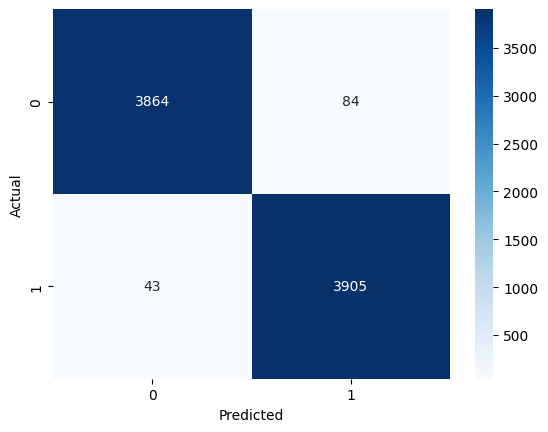

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, test_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
import pickle
pickle.dump(model1,open('model1.pkl','wb'))
model1 = pickle.load(open('model1.pkl','rb'))

## **Model 2: svm**

In [14]:
from sklearn.svm import SVC
model2 = SVC()
model2.fit(X_train,Y_train)

SVC()

In [15]:
ym_pred = model2.predict(X_val)
accuracy_score(Y_val,ym_pred)
print(confusion_matrix(Y_val,ym_pred))
print(classification_report(Y_val,ym_pred))

[[5506  416]
 [ 126 5795]]
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95      5922
         1.0       0.93      0.98      0.96      5921

    accuracy                           0.95     11843
   macro avg       0.96      0.95      0.95     11843
weighted avg       0.96      0.95      0.95     11843



In [16]:
ymtest_pred = model2.predict(X_test)
accuracy_score(Y_test,ymtest_pred)
print(confusion_matrix(Y_test,ymtest_pred))
print(classification_report(Y_test,ymtest_pred))


[[3675  273]
 [  82 3866]]
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95      3948
         1.0       0.93      0.98      0.96      3948

    accuracy                           0.96      7896
   macro avg       0.96      0.96      0.96      7896
weighted avg       0.96      0.96      0.96      7896



In [17]:
pickle.dump(model2,open('model2.pkl','wb'))
model2 = pickle.load(open('model2.pkl','rb'))